In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pl.read_csv("data/cleaned_weather.csv")
df = df.with_columns(pl.col('date').str.to_datetime("%Y-%m-%d %H:%M:%S"))
df.head()

date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.6,224.3,0.0,0.0,0.0,0.0,0.0,11.45
2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.6
2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.7
2020-01-01 00:50:00,1008.61,0.33,272.82,-1.5,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.4,209.6,0.0,0.0,0.0,0.0,0.0,11.81


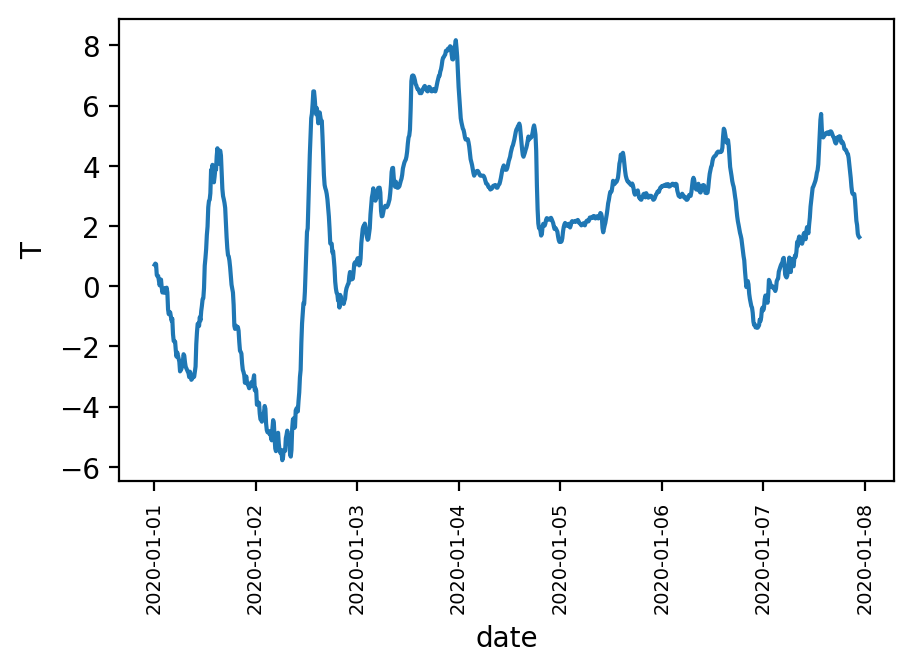

In [4]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=200)
sns.lineplot(data=df[:1000], x='date', y='T', ax=ax)
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')

In [5]:
df = df.with_columns(
    pl.col('date').dt.time().alias('time'),
    pl.col('date').dt.date().alias('day')
)

In [6]:
mean_T = (
    df.group_by("day", maintain_order=True)
    .mean()
    .drop(['date'])
)
mean_T

day,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog,time
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,time
2020-01-01,1006.958811,-0.514196,272.106084,-2.569231,86.429301,5.961748,5.066923,0.894545,3.136154,5.031888,1284.242238,0.783287,1.456573,173.153846,0.0,0.0,57.698671,95.880979,99.195175,11.88972,12:00:00
2020-01-02,1001.050972,-1.056319,272.024167,-4.215069,80.206042,5.853056,4.513333,1.339722,2.809931,4.509653,1279.685069,1.173403,2.133542,165.250556,0.0,0.0,66.461389,96.849375,100.276042,11.303611,11:55:00
2020-01-03,993.802917,4.835278,278.491042,2.006806,81.975,8.721319,7.114236,1.607569,4.465694,7.160069,1242.085694,3.927153,6.106319,192.667292,0.002083,14.375,11.569375,25.155556,29.956111,14.310139,11:55:00
2020-01-04,998.244236,3.784931,277.084583,0.785764,80.899861,8.038264,6.485694,1.553333,4.050694,6.497083,1252.611111,2.261667,4.695347,248.491667,0.033333,41.805556,8.040208,18.851875,21.601319,13.970833,11:55:00
2020-01-05,1007.105347,2.735,275.336458,-1.018611,76.422639,7.446458,5.682292,1.764861,3.516319,5.641458,1268.925139,1.791528,2.812431,220.305556,0.0,0.0,31.750208,65.250694,77.068194,13.938264,11:55:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-12-28,956.733889,1.693819,278.342292,-1.518264,79.912431,6.93125,5.509167,1.422222,3.589722,5.75875,1210.037778,2.304861,3.613819,178.751389,0.010417,104.791667,21.582153,42.701042,48.791389,12.101944,11:55:00
2020-12-29,963.006528,1.669792,277.798056,0.5475,92.484028,6.924375,6.365694,0.558403,4.121875,6.609931,1217.664722,3.021806,4.350069,193.975972,0.0,2.708333,30.554306,59.704653,77.474028,11.026528,11:55:00
2020-12-30,975.641389,2.621528,277.722569,0.841528,88.136528,7.400278,6.497292,0.903681,4.152222,6.658681,1229.370139,2.322708,3.458125,195.511458,0.0,0.0,29.57125,57.69875,71.993819,12.430347,11:55:00


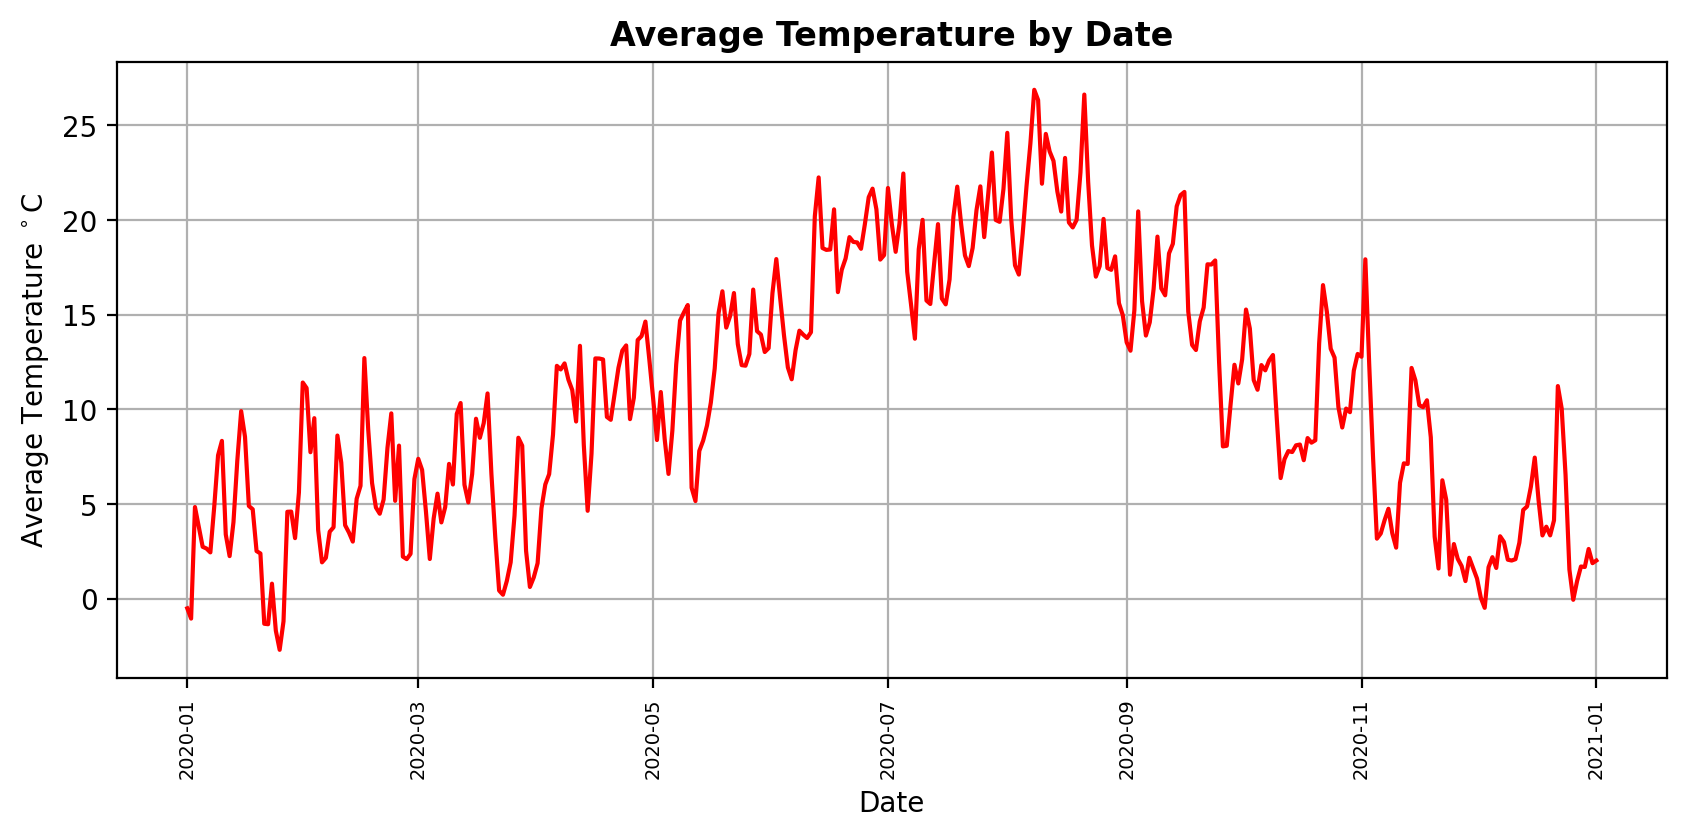

In [7]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(mean_T['day'], mean_T['T'], color='red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Date')
ax.set_ylabel(r'Average Temperature $^\circ$C')
ax.set_title('Average Temperature by Date', fontweight='bold')
ax.grid(True)

In [12]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS


In [18]:
df_modeled = df[:1000]
df_modeled.head()

date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog,time,day
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,time,date
2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.6,224.3,0.0,0.0,0.0,0.0,0.0,11.45,00:10:00,2020-01-01
2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51,00:20:00,2020-01-01
2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.6,00:30:00,2020-01-01
2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.7,00:40:00,2020-01-01
2020-01-01 00:50:00,1008.61,0.33,272.82,-1.5,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.4,209.6,0.0,0.0,0.0,0.0,0.0,11.81,00:50:00,2020-01-01


In [34]:
Y = df_modeled['T'].to_numpy()

In [ ]:
naive_model = AutoETS()
naive_model = naive_model.fit(y=df_modeled['T'].to_numpy())

In [102]:
h = 100
naive_model.predict(h=h)

{'mean': array([1.57326225, 1.51652961, 1.4711435 , 1.43483461, 1.4057875 ,
        1.38254981, 1.36395966, 1.34908754, 1.33718984, 1.32767168,
        1.32005716, 1.31396554, 1.30909224, 1.3051936 , 1.30207469,
        1.29957956, 1.29758346, 1.29598658, 1.29470907, 1.29368707,
        1.29286947, 1.29221538, 1.29169212, 1.2912735 , 1.29093861,
        1.2906707 , 1.29045637, 1.29028491, 1.29014774, 1.290038  ,
        1.28995021, 1.28987998, 1.28982379, 1.28977885, 1.28974289,
        1.28971412, 1.28969111, 1.2896727 , 1.28965797, 1.28964618,
        1.28963676, 1.28962922, 1.28962318, 1.28961836, 1.2896145 ,
        1.28961141, 1.28960894, 1.28960696, 1.28960538, 1.28960411,
        1.2896031 , 1.28960229, 1.28960164, 1.28960113, 1.28960071,
        1.28960038, 1.28960011, 1.2895999 , 1.28959973, 1.2895996 ,
        1.28959949, 1.2895994 , 1.28959933, 1.28959927, 1.28959923,
        1.28959919, 1.28959917, 1.28959914, 1.28959913, 1.28959911,
        1.2895991 , 1.28959909, 1.289599

In [47]:
df_modeled['date'].tail()

date
datetime[μs]
2020-01-07 21:10:00
2020-01-07 21:20:00
2020-01-07 21:30:00
2020-01-07 21:40:00
2020-01-07 21:50:00
2020-01-07 22:00:00
2020-01-07 22:10:00
2020-01-07 22:20:00
2020-01-07 22:30:00


In [53]:
df_modeled['date'][-4:]

date
datetime[μs]
2020-01-07 22:10:00
2020-01-07 22:20:00
2020-01-07 22:30:00
2020-01-07 22:40:00


In [81]:
type(df_modeled['date'].to_numpy())

numpy.ndarray

In [88]:
float(10)

10.0

In [104]:
from datetime import datetime, timedelta
last_obs_time = df_modeled['date'][-1]
#print(last_obs_time  + timedelta(minutes=10))

#horizon = [ x for x in np.arange(0,4)]
horizon = np.array([])
for t in np.arange(start = 10, stop = h*10+1, step = 10):
    horizon = np.append(horizon, last_obs_time + timedelta(minutes=float(t)))

#print(horizon)


In [99]:
naive_model.predict(h=4)['mean']

array([1.57326225, 1.51652961, 1.4711435 , 1.43483461])

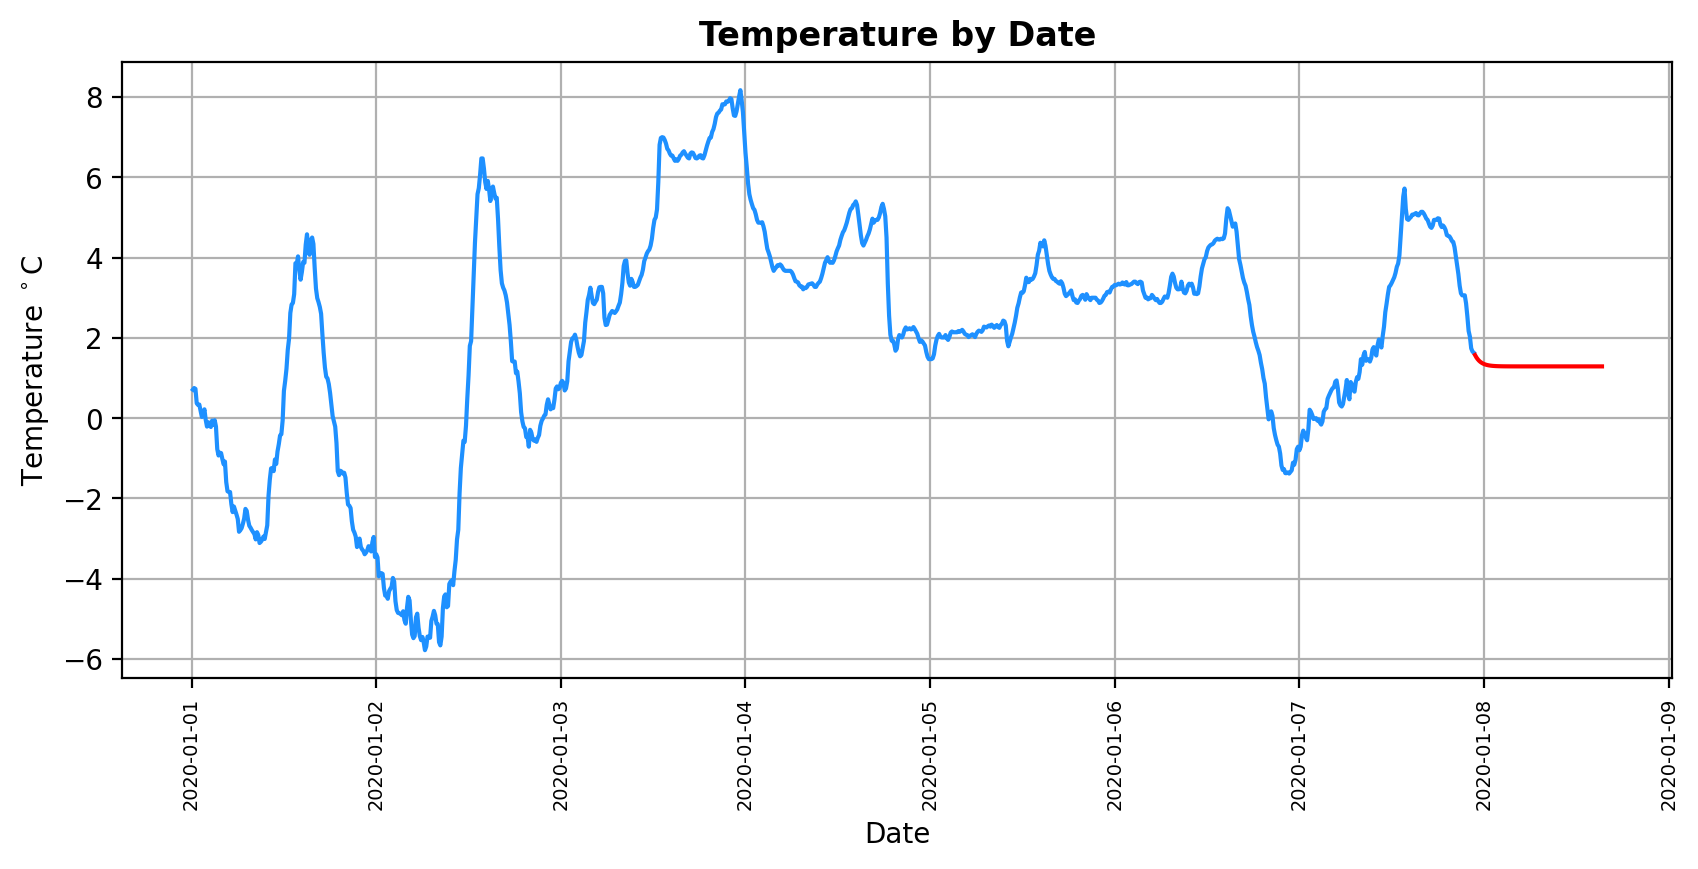

In [106]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(df_modeled['date'], df_modeled['T'], color='dodgerblue')
ax.plot(horizon, naive_model.predict(h=h)['mean'], color = 'red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Date')
ax.set_ylabel(r'Temperature $^\circ$C')
ax.set_title('Temperature by Date', fontweight='bold')
ax.grid(True)

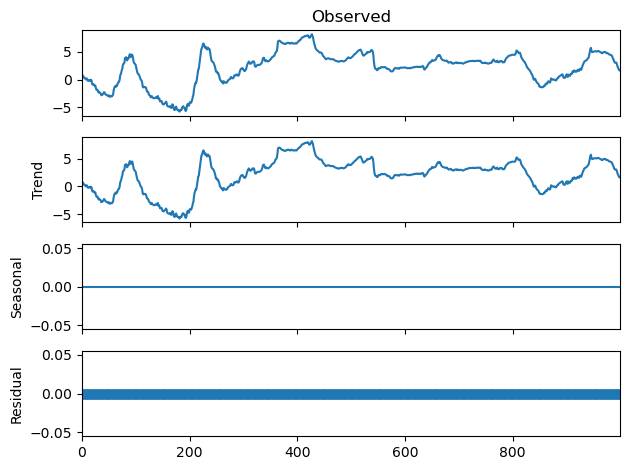

In [124]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed=seasonal_decompose(df_modeled["T"], model = "add", period=1)
decomposed.plot()
plt.show()

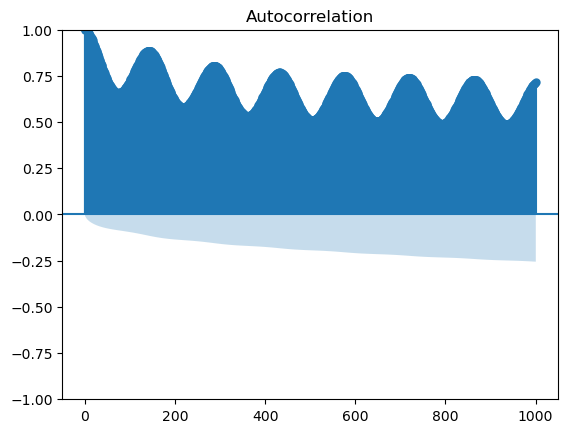

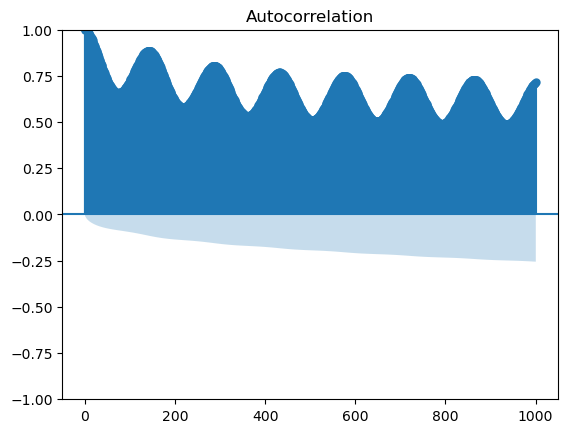

In [127]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['T'], lags = 1000)

Ben's scratch work

In [50]:
X = df.drop(['T', 'time', 'day']).to_numpy()
y = df['T'].to_numpy()

model = AutoETS()
model = model.fit(y=y, X=X)

h = 6*24*30
predictions = model.predict(h=h)

In [51]:
last_obs_time = df['date'][-1]
horizon = np.array([])
for t in np.arange(start=10, stop=h*10+1, step=10):
    horizon = np.append(horizon, last_obs_time + timedelta(minutes=float(t)))

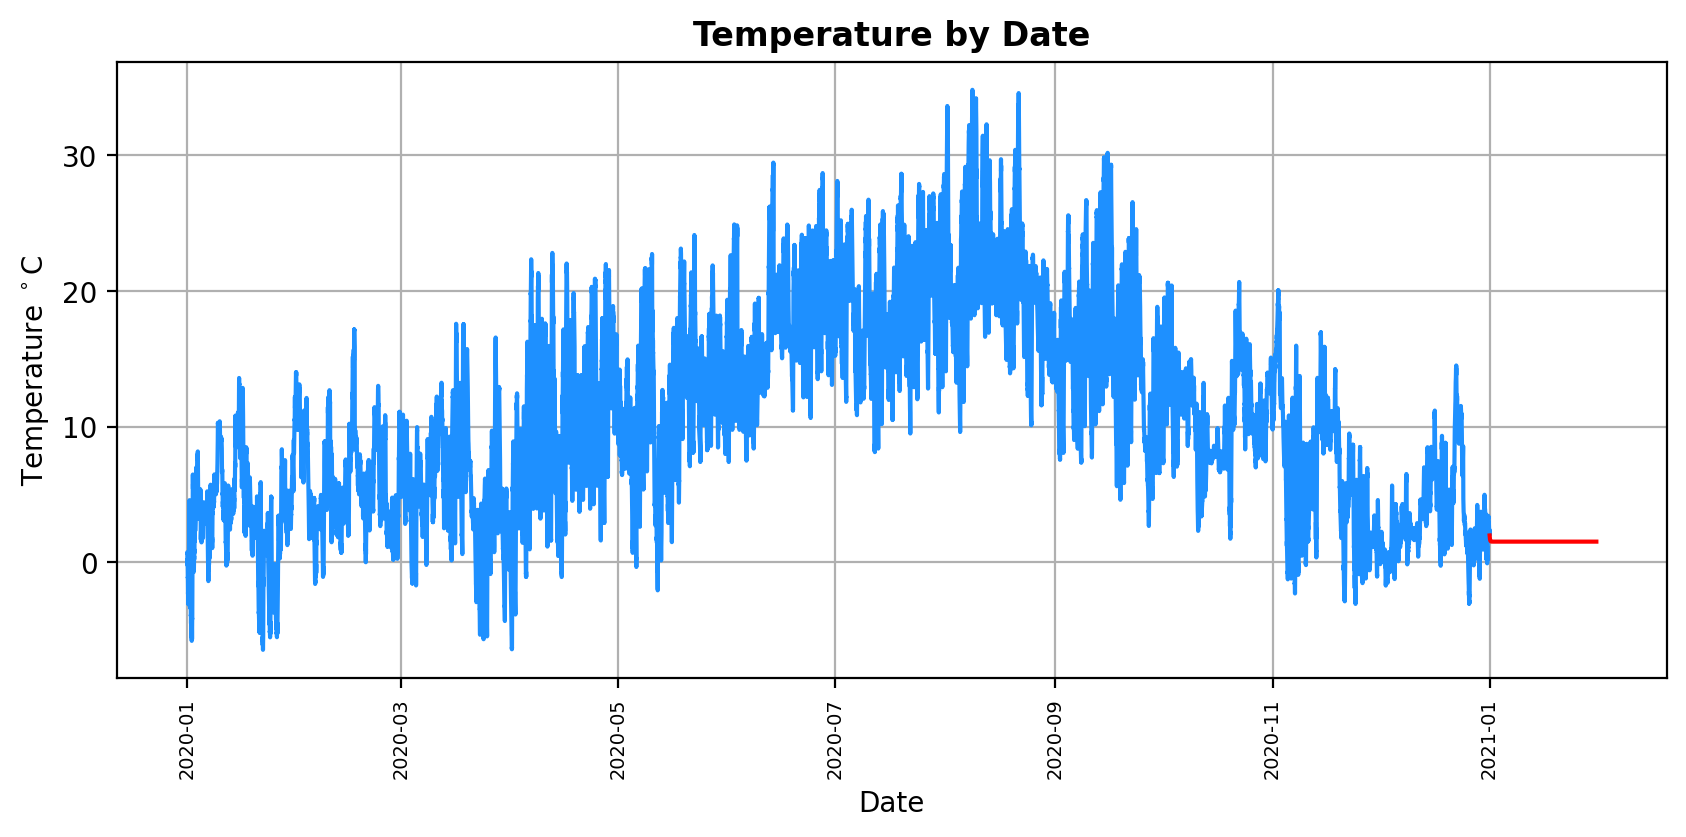

In [52]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(df['date'], df['T'], color='dodgerblue')
ax.plot(horizon, predictions['mean'], color='red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Date')
ax.set_ylabel(r'Temperature $^\circ$C')
ax.set_title('Temperature by Date', fontweight='bold')
ax.grid(True)

In [122]:
from statsforecast.models import AutoARIMA
arima_model = AutoARIMA(seasonal=True, stationary=False)
arima_model = arima_model.fit(y=df_modeled['T'].to_numpy())

In [116]:
from datetime import datetime, timedelta
last_obs_time = df_modeled['date'][-1]
#print(last_obs_time  + timedelta(minutes=10))

#horizon = [ x for x in np.arange(0,4)]
horizon = np.array([])
for t in np.arange(start = 10, stop = h*10+1, step = 10):
    horizon = np.append(horizon, last_obs_time + timedelta(minutes=float(t)))

In [118]:
arima_model.forecast(y=df_modeled['T'].to_numpy(), h = 10)

{'mean': array([1.56143285, 1.47848172, 1.39917289, 1.32546744, 1.25696949,
        1.19331111, 1.13415037, 1.07916949, 1.02807317, 0.98058694])}

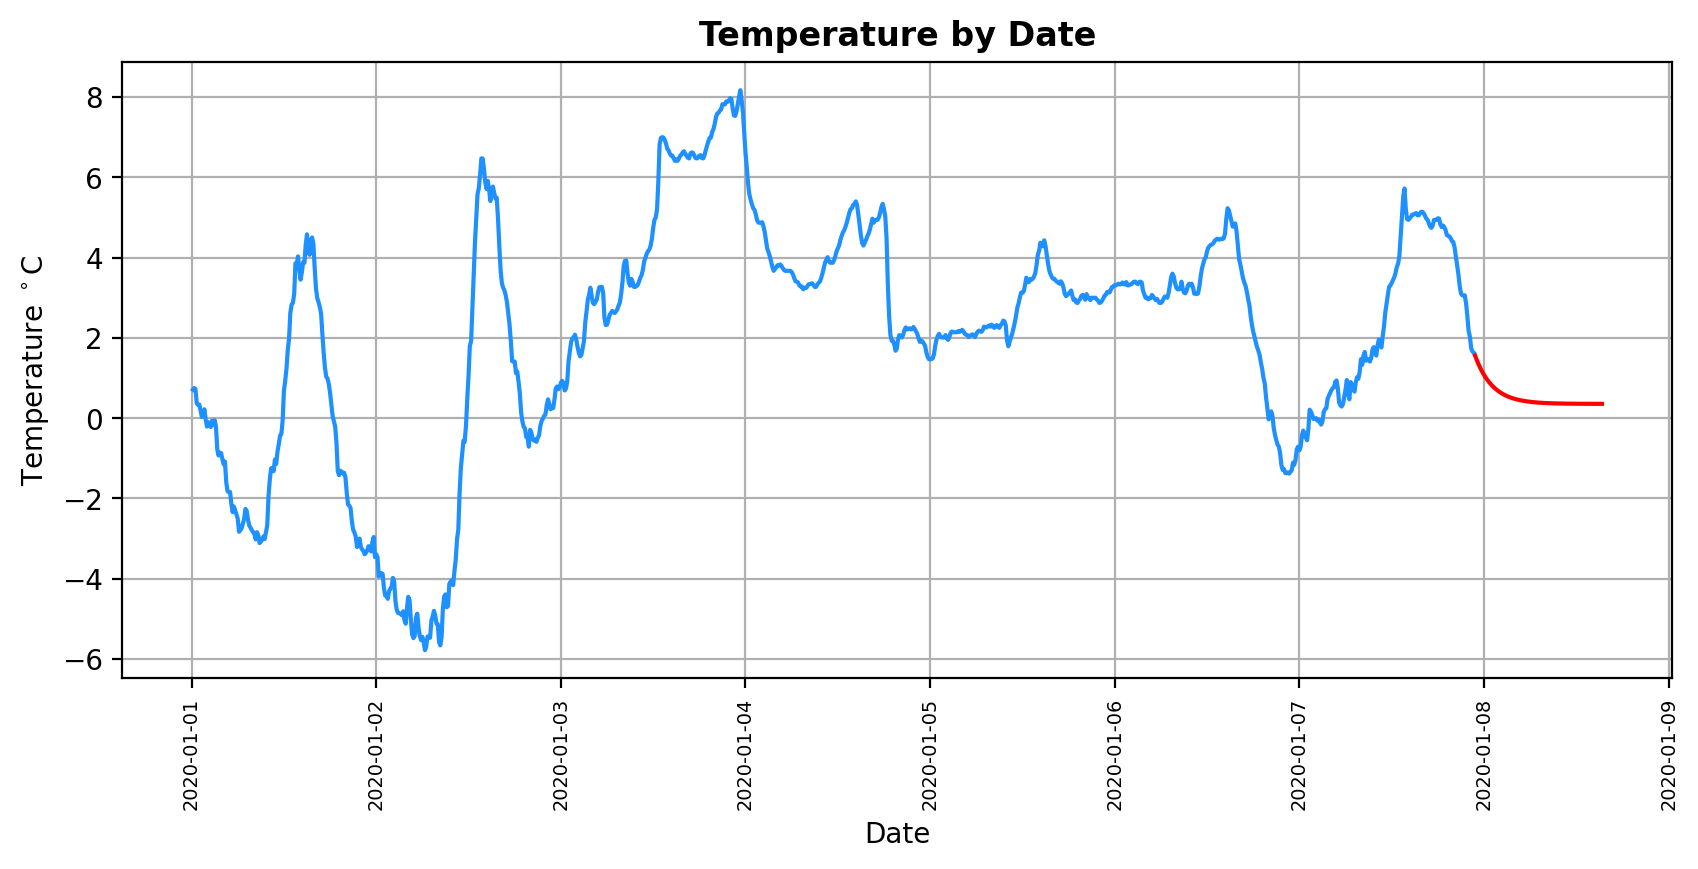

In [119]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(df_modeled['date'], df_modeled['T'], color='dodgerblue')
ax.plot(horizon, arima_model.forecast(y=df_modeled['T'].to_numpy(), h = h)['mean'], color = 'red')
ax.tick_params(axis='x', labelrotation=90, labelsize='x-small')
ax.set_xlabel('Date')
ax.set_ylabel(r'Temperature $^\circ$C')
ax.set_title('Temperature by Date', fontweight='bold')
ax.grid(True)